In this notebook I try to find the amplitude of the periodic signal (a.k.a. the orbital period of GRACE of 94.5 minutes) and see if it varies over time.

# Imports and reads

In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
from utils.data_loader import load_parquet

# Load only specific columns that you need for analysis
# This will significantly reduce memory usage
columns_needed = ['time', 'orbital_decay']

GFOC_data = load_parquet(columns=columns_needed)
print(GFOC_data.head())

✅ Successfully loaded data with shape: (3157920, 2)
                 time  orbital_decay
0 2023-01-01 00:00:00        16.6730
1 2023-01-01 00:00:20        16.6730
2 2023-01-01 00:00:40        16.6735
3 2023-01-01 00:01:00        16.6740
4 2023-01-01 00:01:20        16.6740


In [2]:
df = GFOC_data.copy()
time = df['time'].values

# make 'time' the index
df.set_index('time', inplace=True)

# BASE_PATH = '/Users/vanessa/PhD/Dev/SELAnalysis/SpaceWeatherImpact/data/2023-01-01_2024-12-31/processed/'
# df = pd.read_parquet(BASE_PATH + 'SWMA_RDAWFI.parquet', columns=['orbital_decay', '|avg B|', 'F10.7 (LASP)'])
df.index = pd.to_datetime(df.index)
df = df.resample('30s').mean()
# df['num_index'] = df.reset_index().index

np.random.seed(42)

# Test

In [3]:
from utils.plot_loader import create_subset

df_subset = create_subset(GFOC_data, start_date='2023-10-31', end_date='2023-11-04', resample_rate='30s')
# df_subset.set_index('time', inplace=True)
df_subset.index = pd.to_datetime(df_subset.index)

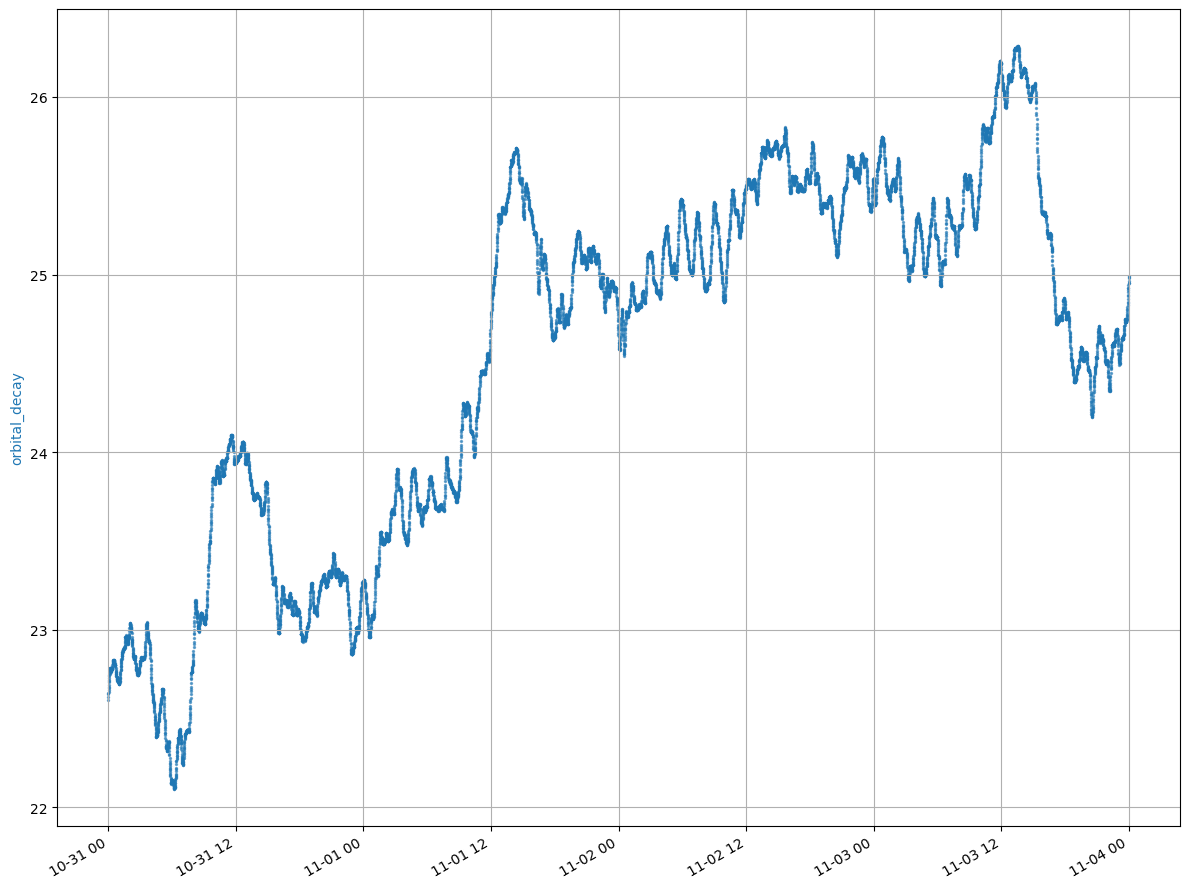

In [4]:
# plot all features from columns_needed
fig, axes = plt.subplots(1, 1, figsize=(12, 9), sharex=True)

axes.scatter(df_subset.index, df_subset['orbital_decay'], s=2, c='C0', alpha=0.6)
axes.set_ylabel('orbital_decay', color='C0')
axes.grid(True)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## STL filter

using a period of 94.5 minutes
72.1 ms ± 475 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


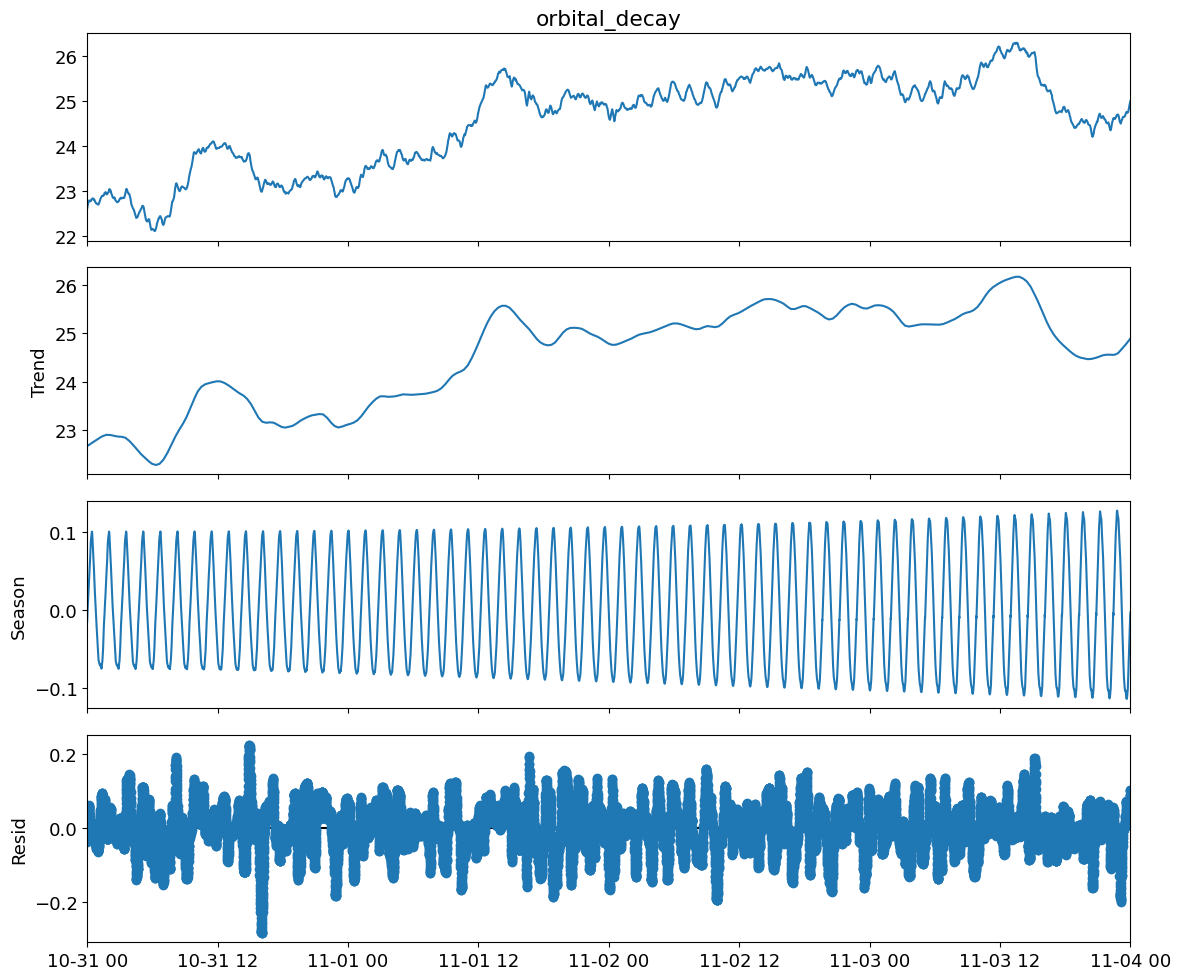

In [5]:
# Use time as index for y
y = df_subset.copy()
# y.describe()

# performance
period = int(94.5 * 2) # 94.5 minutes
print(f"using a period of {period/2} minutes")
seasonal = 100 * period + ((period % 2) != 0)  # Ensure odd
low_pass_jump = seasonal_jump = int(0.15 * (period + 1))
trend_jump = int(0.15 * 1.5 * (period + 1))


mod = STL(
    y['orbital_decay'],
    period=period,
    seasonal=seasonal,
    seasonal_jump=seasonal_jump,
    trend_jump=trend_jump,
    low_pass_jump=low_pass_jump,
)
%timeit mod.fit()
res = mod.fit()

# plot
plt.rc("figure", figsize=(12, 10))
plt.rc("font", size=13)
fig = res.plot()

### Find amplitude

In [6]:
res_seasonal = res.seasonal
amplitude1 = (res_seasonal[:4*period].max() - res_seasonal[:4*period].min()) / 2
print(f"Max Seasonal amplitude: {amplitude1}")
amplitude2 = (res_seasonal[-4*period:].max() - res_seasonal[-4*period:].min()) / 2
print(f"Max Seasonal amplitude: {amplitude2}")
mid = int(len(res_seasonal)/2)
amplitude3 = (res_seasonal[mid-2*period:mid+2*period].max() - res_seasonal[mid-2*period:mid+2*period].min()) / 2
print(f"Max Seasonal amplitude: {amplitude3}")
min_amplitude = min(amplitude1, amplitude2, amplitude3)
max_amplitude = max(amplitude1, amplitude2, amplitude3)

print(f"Average Seasonal amplitude: {(min_amplitude + max_amplitude)/2:.3} +- {(max_amplitude - min_amplitude)/2:.3}")

Max Seasonal amplitude: 0.08806686113385459
Max Seasonal amplitude: 0.1207809104417773
Max Seasonal amplitude: 0.10014592943739811
Average Seasonal amplitude: 0.104 +- 0.0164


In [7]:
from scipy.signal import hilbert
results = []
res_seasonal = res.seasonal
envelope = np.abs(hilbert(res_seasonal))
amp_mean = np.mean(envelope)
amp_median = np.median(envelope)
amp_std = np.std(envelope)

# store summary per window
results.append({
    'amp_mean': amp_mean,
    'amp_median': amp_median,
    'amp_std': amp_std,
})
print(results)

[{'amp_mean': np.float64(0.09894157330746474), 'amp_median': np.float64(0.09913215193696223), 'amp_std': np.float64(0.011972600179584474)}]


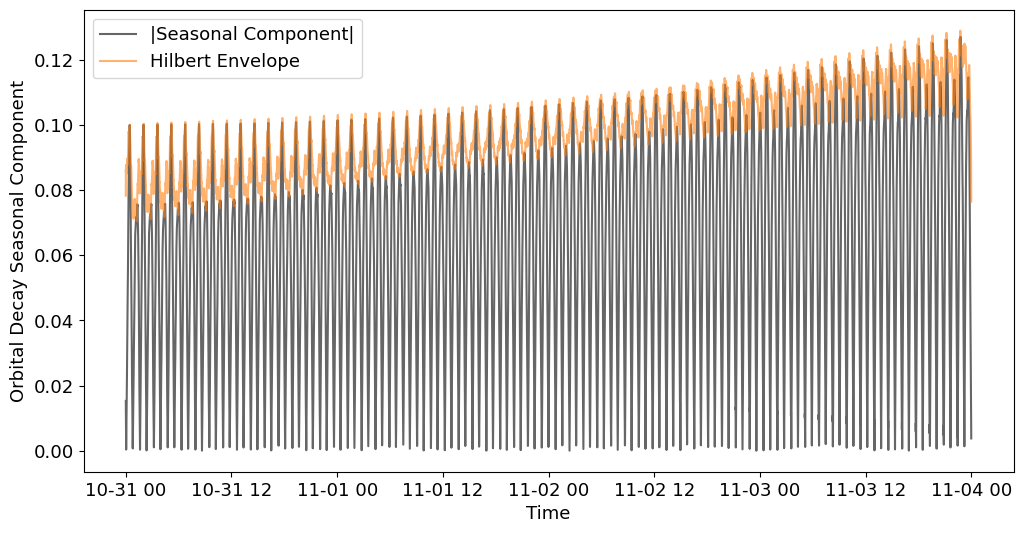

In [8]:
plt.figure(figsize=(12, 6))
# plt.plot(res_seasonal.index, res_seasonal, label='Seasonal Component', c='C0')
plt.plot(res_seasonal.index, np.abs(res_seasonal), label='|Seasonal Component|', c='black', alpha=0.6)
plt.plot(res_seasonal.index, np.abs(hilbert(res_seasonal)), label='Hilbert Envelope', c='C1', alpha=0.6)
plt.xlabel('Time')
plt.ylabel('Orbital Decay Seasonal Component')
plt.legend()
plt.show()

The oscillation of the hilbert envelope can be explained by a systematic offset: the positive amplitude is lower than the negative amplitude. This can be seen if I plot the absolute value of the seasonal component. Thus the Hilber envelope captures that offset very well and can give some statistics about it.

### Determin dominant Period

Most significant period: 94.32 minutes


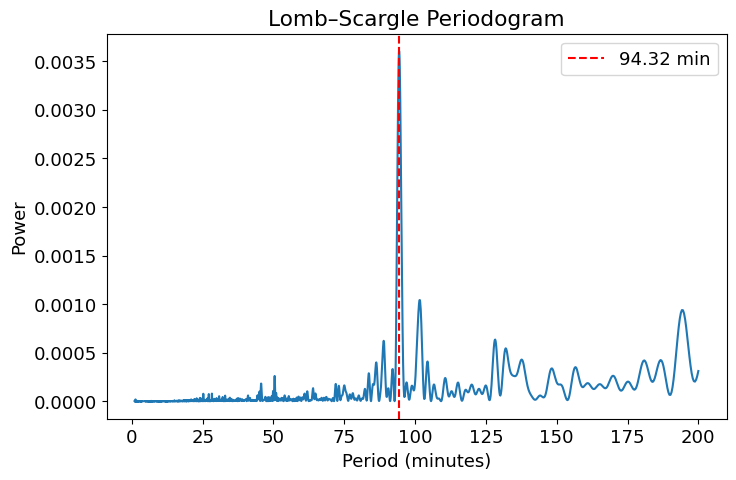

In [9]:
# do a lomb-scargle analysis on the seasonal component to find dominant frequencies
from astropy.timeseries import LombScargle

# convert time for lomb-scargle
t = y.index.astype(np.int64) / (1e9 * 60)  # convert to minutes
t = t - t.min()  # start at zero

# Define frequency range in cycles per minute
min_period = 1        # minutes
max_period = 200     # minutes
min_freq = 1 / max_period
max_freq = 1 / min_period

# Compute Lomb–Scargle
frequency = np.linspace(min_freq, max_freq, 100000)
power = LombScargle(t, y['orbital_decay'].values).power(frequency)

# Find dominant period
best_frequency = frequency[np.argmax(power)]
best_period = 1 / best_frequency

print(f"Most significant period: {best_period:.2f} minutes")

# Plot
plt.figure(figsize=(8,5))
plt.plot(1/frequency, power)
plt.xlabel('Period (minutes)')
plt.ylabel('Power')
plt.title('Lomb–Scargle Periodogram')
plt.axvline(best_period, color='r', linestyle='--', label=f'{best_period:.2f} min')
plt.legend()
plt.show()

# Rolling Windows

In [10]:
from astropy.timeseries import LombScargle

# Constants
window_days = 6
step_days = 2
dt_seconds = 30
# period_seconds = 94.5 * 60
# period_samples = int(round(period_seconds / dt_seconds))  # 189
# seasonal = 20 * period_samples + ((period_samples % 2) != 0)  # Ensure odd
# low_pass_jump = seasonal_jump = int(0.15 * (period_samples + 1))
# trend_jump = int(0.15 * 1.5 * (period_samples + 1))

# Precompute step sizes
window = pd.Timedelta(days=window_days)
step = pd.Timedelta(days=step_days)

t_start = df.index.min()
t_end = df.index.max()
# t_end = t_start + 30*window  # limit for testing

results = []

t = t_start

# Define frequency range in cycles per minute
min_period = 90        # minutes
max_period = 100     # minutes
min_freq = 1 / max_period
max_freq = 1 / min_period

frequency = np.linspace(min_freq, max_freq, 100000)

while t + window <= t_end:
    subset = df.loc[t : t + window, 'orbital_decay']

    # Lomb-Scargle periodogram on seasonal component
    t_ls = subset.index.copy()
    t_ls = (subset.index.astype(np.int64) / (1e9 * 60))  # convert to minutes
    t_ls = t_ls - t_ls.min()  # start at zero
    power = LombScargle(t_ls, subset.values).power(frequency)
    best_frequency = frequency[np.argmax(power)]
    best_period = 1 / best_frequency

    period_seconds = best_period * 60
    period_samples = int(round(period_seconds / dt_seconds))  # 189
    seasonal = 20 * period_samples + (20 * period_samples % 2 == 0) # Ensure odd
    low_pass_jump = seasonal_jump = int(0.15 * (period_samples + 1))
    trend_jump = int(0.15 * 1.5 * (period_samples + 1))

    if len(subset) < period_samples * 3:
        # too few points — skip
        t += step
        continue

    # STL decomposition
    stl = STL(
        subset,
        period=period_samples,
        seasonal=seasonal,
        seasonal_jump=seasonal_jump,
        trend_jump=trend_jump,
        low_pass_jump=low_pass_jump,
    )
    res = stl.fit()

    # compute amplitude my method
    res_seasonal = res.seasonal
    amplitude1 = (res_seasonal[:4*period].max() - res_seasonal[:4*period].min()) / 2
    amplitude2 = (res_seasonal[-4*period:].max() - res_seasonal[-4*period:].min()) / 2
    mid = int(len(res_seasonal)/2)
    amplitude3 = (res_seasonal[mid-2*period:mid+2*period].max() - res_seasonal[mid-2*period:mid+2*period].min()) / 2
    min_amplitude = min(amplitude1, amplitude2, amplitude3)
    max_amplitude = max(amplitude1, amplitude2, amplitude3)

    # compute amplitude from seasonal component via Hilbert envelope
    envelope = np.abs(hilbert(res_seasonal))
    amp_mean = np.mean(envelope)
    amp_median = np.median(envelope)
    amp_std = np.std(envelope)

    # store summary per window
    results.append({
        'window_start': t,
        'window_center': t + window/2,
        'amp_min': min_amplitude,
        'amp_max': max_amplitude,
        'hilbert_amp_mean': amp_mean,
        'hilbert_amp_median': amp_median,
        'hilbert_amp_std': amp_std,
        'trend_mean': np.mean(res.trend.values),
        'orbital_period': best_period
    })

    # advance window
    t += step

# Collect results
amp_df = pd.DataFrame(results).set_index('window_center')

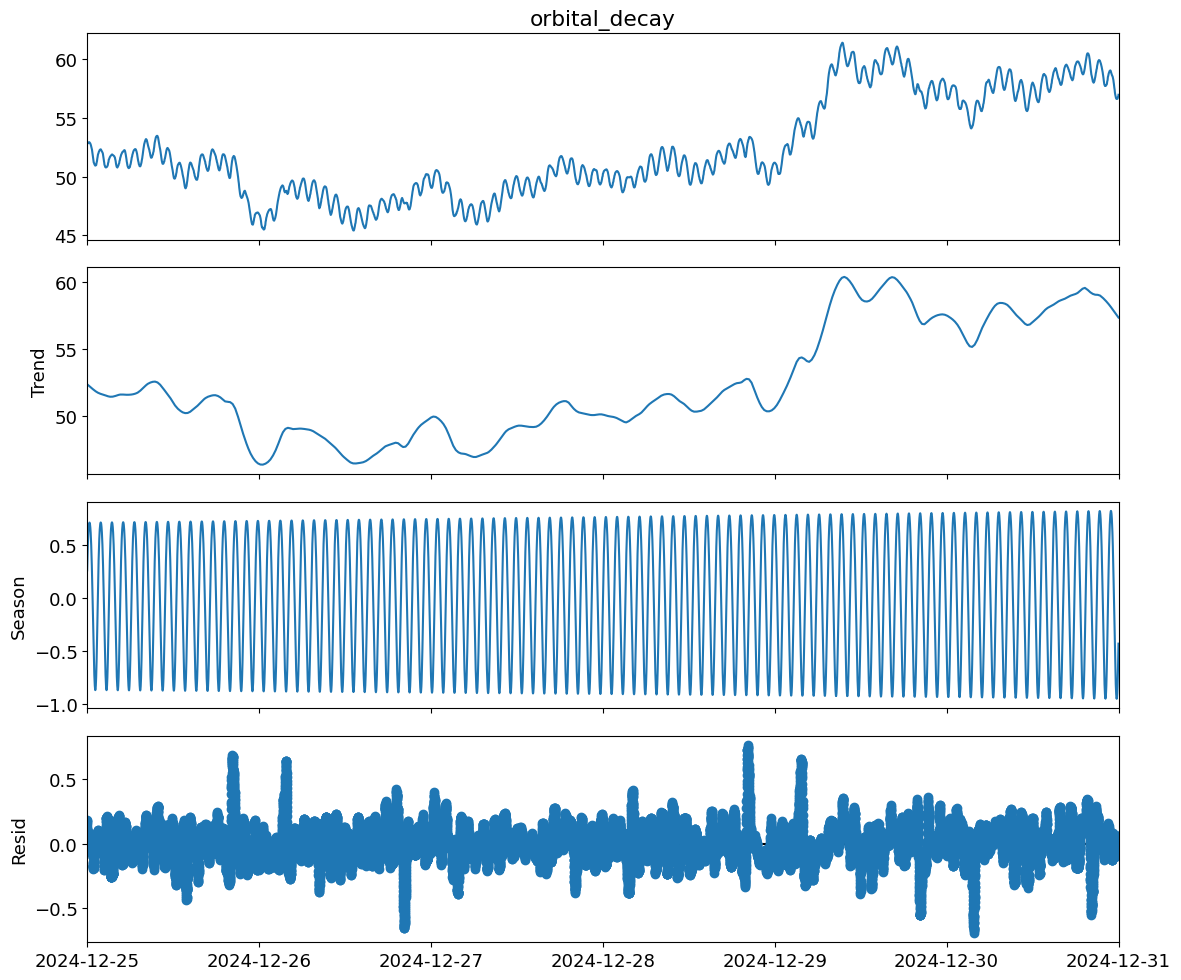

In [11]:
fig = res.plot()

# Plot result

In [12]:
# fit a polynomal to the orbital period over time
from numpy.polynomial import Polynomial
# Convert time to seconds
x = (amp_df.index.astype(np.int64) / 1e9).values
y = amp_df['orbital_period'].values

# --- Parameters ---
deg = 1           # polynomial degree
n_iter = 5        # number of IRLS iterations
c = 4.685         # tuning constant for Tukey’s biweight (robustness level)

# --- Initialize ---
p = Polynomial.fit(x, y, deg)
for _ in range(n_iter):
    y_pred = p(x)
    resid = y - y_pred
    mad = np.median(np.abs(resid - np.median(resid)))  # robust scale
    u = resid / (1.4826 * mad + 1e-8)  # normalized residuals

    # Tukey’s biweight function
    w = np.clip((1 - (u / c)**2), 0, 1)**2

    # Refit using weights
    p = Polynomial.fit(x, y, deg, w=w)

# --- Final smooth fit ---
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = p(x_fit)

print(p.convert().coef)

[ 1.06605722e+02 -7.21846851e-09]


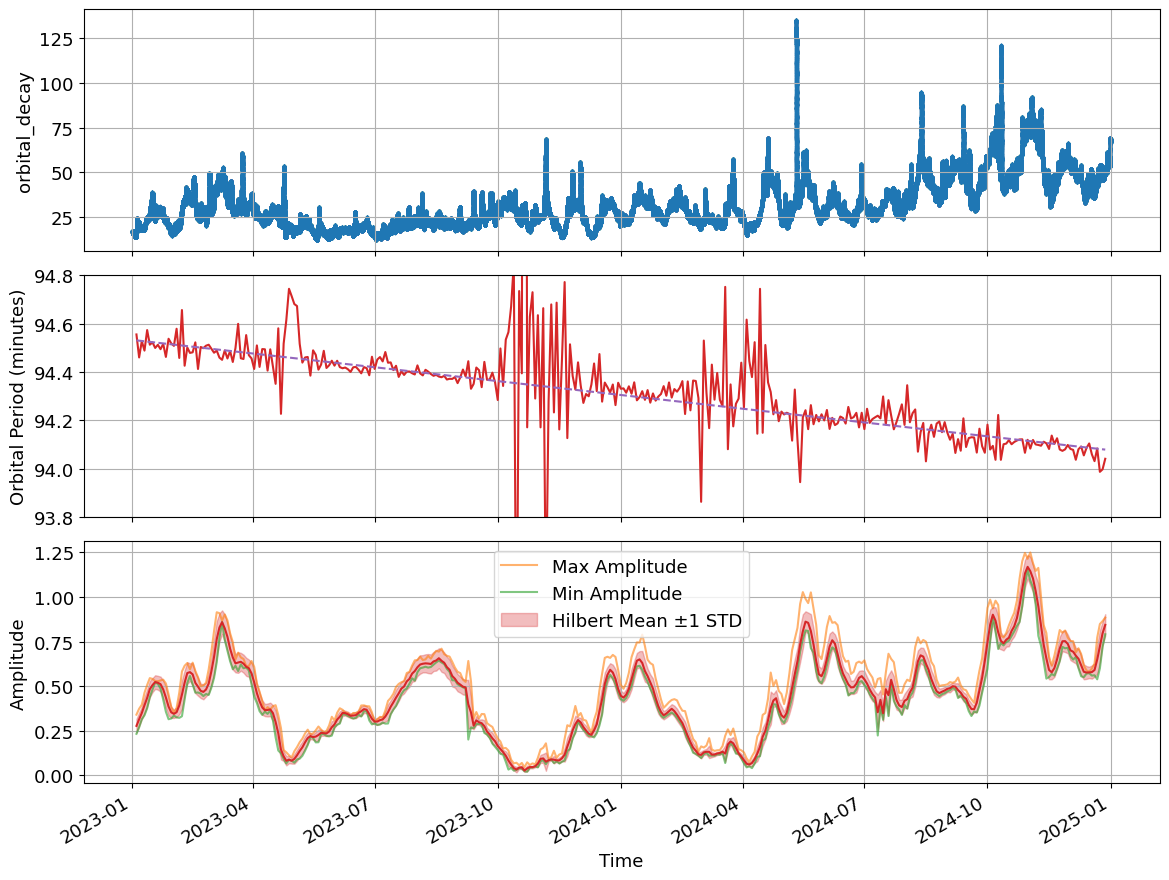

In [13]:
# plot all features from columns_needed
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].scatter(df.index, df['orbital_decay'], s=2, c='C0', alpha=0.6)
axes[0].set_ylabel('orbital_decay')
axes[0].grid(True)

axes[1].plot(amp_df.index, amp_df['orbital_period'], c='C3')
# axes[1].plot(pd.to_datetime(x_fit*1e9), y_fit, c='C4', linestyle='--', label='Polynomial Fit (deg=2)')
axes[1].plot(amp_df.index, p(amp_df.index.astype(np.int64) / 1e9), c='C4', linestyle='--', label='Polynomial Fit (deg=1)')
axes[1].set_ylabel('Orbital Period (minutes)')
# axes[1].set_xlabel('Time')
axes[1].set_ylim(93.8, 94.8)
axes[1].grid(True)

axes[2].plot(amp_df.index, amp_df['amp_max'], c='C1', alpha=0.6, label='Max Amplitude')
axes[2].plot(amp_df.index, amp_df['amp_min'], c='C2', alpha=0.6, label='Min Amplitude')
axes[2].plot(amp_df.index, amp_df['hilbert_amp_mean'], c='C3')
axes[2].fill_between(amp_df.index, amp_df['hilbert_amp_mean']-amp_df['hilbert_amp_std'], amp_df['hilbert_amp_mean']+amp_df['hilbert_amp_std'], color='C3', alpha=0.3, label = 'Hilbert Mean ±1 STD')
axes[2].legend()
axes[2].set_ylabel('Amplitude')
axes[2].set_xlabel('Time')
axes[2].grid(True)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Does fitting the period make the amplitude curve change?

In [14]:
from astropy.timeseries import LombScargle

# Constants
window_days = 6
step_days = 2
dt_seconds = 30

# Precompute step sizes
window = pd.Timedelta(days=window_days)
step = pd.Timedelta(days=step_days)

t_start = df.index.min()
t_end = df.index.max()
# t_end = t_start + 30*window  # limit for testing

results2 = []

t = t_start

frequency = np.linspace(min_freq, max_freq, 100000)

while t + window <= t_end:
    subset = df.loc[t : t + window, 'orbital_decay']

    # Lomb-Scargle periodogram on seasonal component
    mean_t = t + window/2
    best_period = p(mean_t.value / 1e9)

    period_seconds = best_period * 60
    period_samples = int(round(period_seconds / dt_seconds))  # 189
    seasonal = 20 * period_samples + (20 * period_samples % 2 == 0) # Ensure odd
    low_pass_jump = seasonal_jump = int(0.15 * (period_samples + 1))
    trend_jump = int(0.15 * 1.5 * (period_samples + 1))

    if len(subset) < period_samples * 3:
        # too few points — skip
        t += step
        continue

    # STL decomposition
    stl = STL(
        subset,
        period=period_samples,
        seasonal=seasonal,
        seasonal_jump=seasonal_jump,
        trend_jump=trend_jump,
        low_pass_jump=low_pass_jump,
    )
    res = stl.fit()

    # compute amplitude my method
    res_seasonal = res.seasonal
    amplitude1 = (res_seasonal[:4*period].max() - res_seasonal[:4*period].min()) / 2
    amplitude2 = (res_seasonal[-4*period:].max() - res_seasonal[-4*period:].min()) / 2
    mid = int(len(res_seasonal)/2)
    amplitude3 = (res_seasonal[mid-2*period:mid+2*period].max() - res_seasonal[mid-2*period:mid+2*period].min()) / 2
    min_amplitude = min(amplitude1, amplitude2, amplitude3)
    max_amplitude = max(amplitude1, amplitude2, amplitude3)

    # compute amplitude from seasonal component via Hilbert envelope
    envelope = np.abs(hilbert(res_seasonal))
    amp_mean = np.mean(envelope)
    amp_median = np.median(envelope)
    amp_std = np.std(envelope)

    # store summary per window
    results2.append({
        'window_start': t,
        'window_center': t + window/2,
        'amp_min': min_amplitude,
        'amp_max': max_amplitude,
        'hilbert_amp_mean': amp_mean,
        'hilbert_amp_median': amp_median,
        'hilbert_amp_std': amp_std,
        'trend_mean': np.mean(res.trend.values),
        'orbital_period': best_period
    })

    # advance window
    t += step

# Collect results
amp2_df = pd.DataFrame(results2).set_index('window_center')

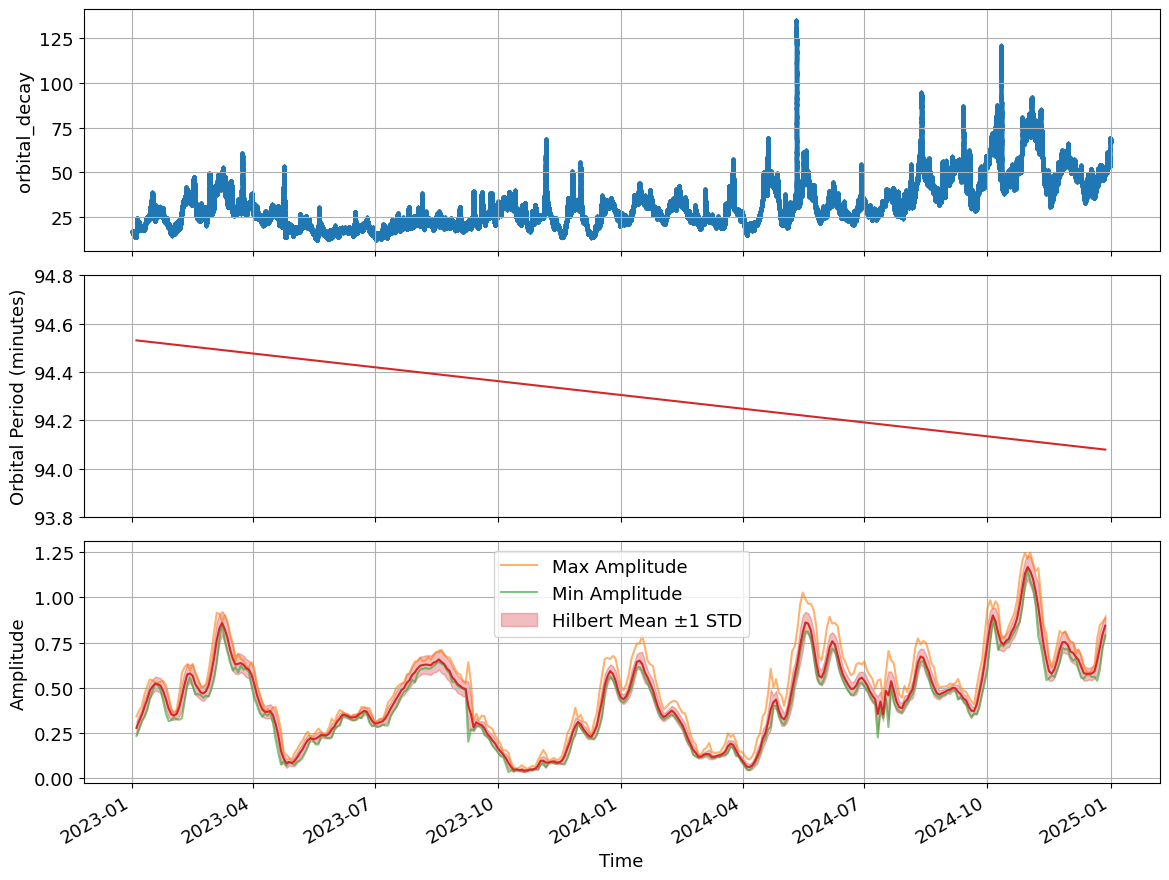

In [15]:
# plot all features from columns_needed
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].scatter(df.index, df['orbital_decay'], s=2, c='C0', alpha=0.6)
axes[0].set_ylabel('orbital_decay')
axes[0].grid(True)

axes[1].plot(amp2_df.index, amp2_df['orbital_period'], c='C3')
axes[1].set_ylabel('Orbital Period (minutes)')
# axes[1].set_xlabel('Time')
axes[1].set_ylim(93.8, 94.8)
axes[1].grid(True)

axes[2].plot(amp2_df.index, amp2_df['amp_max'], c='C1', alpha=0.6, label='Max Amplitude')
axes[2].plot(amp2_df.index, amp2_df['amp_min'], c='C2', alpha=0.6, label='Min Amplitude')
axes[2].plot(amp2_df.index, amp2_df['hilbert_amp_mean'], c='C3')
axes[2].fill_between(amp2_df.index, amp2_df['hilbert_amp_mean']-amp2_df['hilbert_amp_std'], amp2_df['hilbert_amp_mean']+amp2_df['hilbert_amp_std'], color='C3', alpha=0.3, label = 'Hilbert Mean ±1 STD')
axes[2].legend()
axes[2].set_ylabel('Amplitude')
axes[2].set_xlabel('Time')
axes[2].grid(True)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

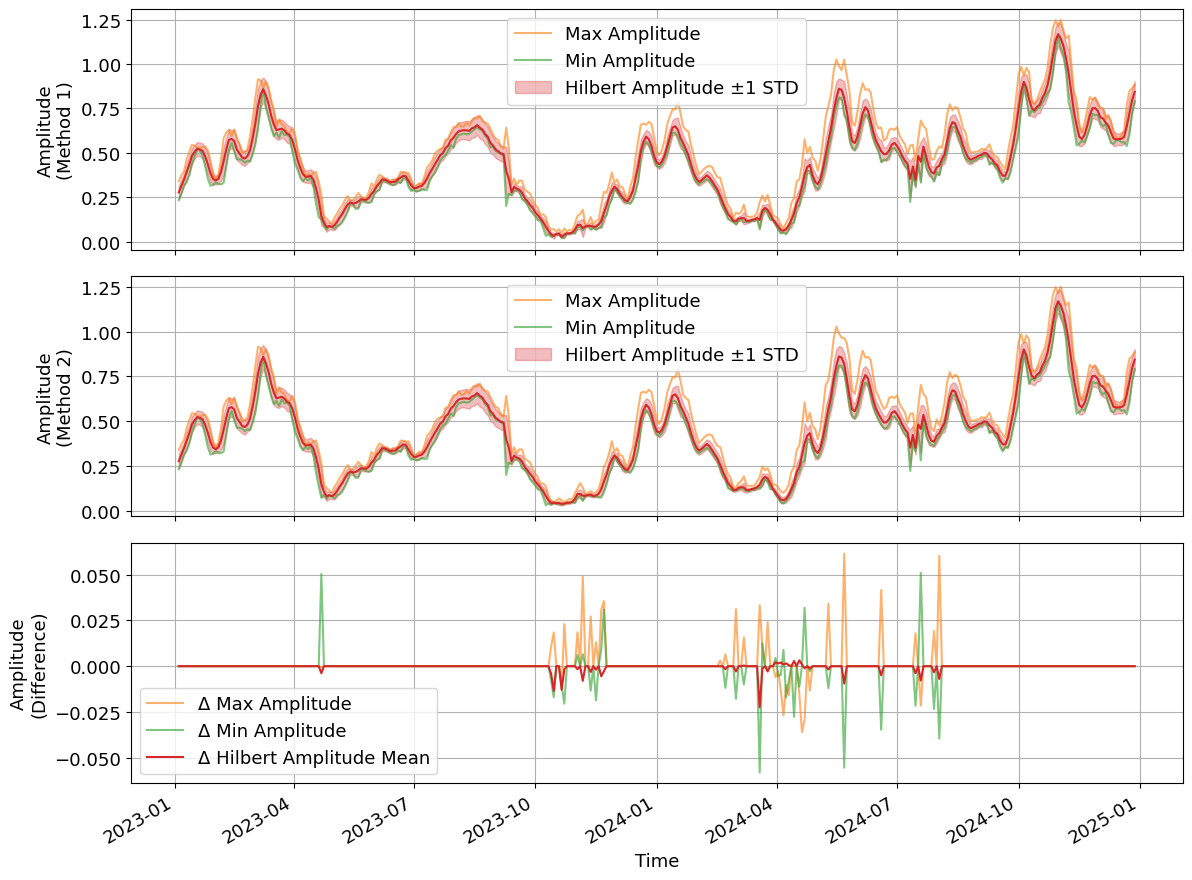

In [16]:
# plot differences between both methods
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(amp_df.index, amp_df['amp_max'], c='C1', alpha=0.6, label='Max Amplitude')
axes[0].plot(amp_df.index, amp_df['amp_min'], c='C2', alpha=0.6, label='Min Amplitude')
axes[0].plot(amp_df.index, amp_df['hilbert_amp_mean'], c='C3')
axes[0].fill_between(amp_df.index, amp_df['hilbert_amp_mean']-amp_df['hilbert_amp_std'], amp_df['hilbert_amp_mean']+amp_df['hilbert_amp_std'], color='C3', alpha=0.3, label = 'Hilbert Amplitude ±1 STD')
axes[0].legend()
axes[0].set_ylabel('Amplitude\n(Method 1)')
axes[0].grid(True)

axes[1].plot(amp2_df.index, amp2_df['amp_max'], c='C1', alpha=0.6, label='Max Amplitude')
axes[1].plot(amp2_df.index, amp2_df['amp_min'], c='C2', alpha=0.6, label='Min Amplitude')
axes[1].plot(amp2_df.index, amp2_df['hilbert_amp_mean'], c='C3')
axes[1].fill_between(amp2_df.index, amp2_df['hilbert_amp_mean']-amp2_df['hilbert_amp_std'], amp2_df['hilbert_amp_mean']+amp2_df['hilbert_amp_std'], color='C3', alpha=0.3, label = 'Hilbert Amplitude ±1 STD')
axes[1].legend()
axes[1].set_ylabel('Amplitude\n(Method 2)')
axes[1].grid(True)

axes[2].plot(amp2_df.index, amp_df['amp_max']-amp2_df['amp_max'], c='C1', alpha=0.6, label='Δ Max Amplitude')
axes[2].plot(amp2_df.index, amp_df['amp_min']-amp2_df['amp_min'], c='C2', alpha=0.6, label='Δ Min Amplitude')
axes[2].plot(amp2_df.index, amp_df['hilbert_amp_mean']-amp2_df['hilbert_amp_mean'], c='C3', label='Δ Hilbert Amplitude Mean')
axes[2].legend()
axes[2].set_ylabel('Amplitude\n(Difference)')
axes[2].set_xlabel('Time')
axes[2].grid(True)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()